**Task 1 = Data Loading, Merging & Deep Exploration**

In [74]:
import os
os.makedirs('charts', exist_ok=True)

In [1]:
import pandas as pd
df = pd.read_csv('train.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [2]:
df['Order Date'].head()

,Order Date
0,08/11/2017
1,08/11/2017
2,12/06/2017
3,11/10/2016
4,11/10/2016


In [3]:
df['Order Date'].str.split('/').str[0].astype(int).max()

31

In [4]:
df['Order Date'].str.split('/').str[1].astype(int).max()

12

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

In [6]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.dayofweek
df['Quarter'] = df['Order Date'].dt.quarter

In [7]:
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    else:
        return 'Fall'

In [8]:
df['Season'] = df['Month'].apply(get_season)

In [9]:
df[['Order Date','Month','Season','Week','DayOfWeek','Quarter']].head(10)

,Order Date,Month,Season,Week,DayOfWeek,Quarter
0,2017-11-08,11,Fall,45,2,4
1,2017-11-08,11,Fall,45,2,4
2,2017-06-12,6,Summer,24,0,2
3,2016-10-11,10,Fall,41,1,4
4,2016-10-11,10,Fall,41,1,4
5,2015-06-09,6,Summer,24,1,2
6,2015-06-09,6,Summer,24,1,2
7,2015-06-09,6,Summer,24,1,2
8,2015-06-09,6,Summer,24,1,2
9,2015-06-09,6,Summer,24,1,2


In [10]:
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week              0
DayOfWeek         0
Quarter           0
Season            0
dtype: int64
Duplicate rows: 0


In [11]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

In [12]:
daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [13]:
daily_sales.shape

(1230, 2)

In [14]:
daily_sales = daily_sales.set_index('Order Date')
full_range = pd.date_range(start=daily_sales.index.min(), end=daily_sales.index.max(), freq='D')
daily_sales = daily_sales.reindex(full_range, fill_value=0)
daily_sales.index.name = 'Order Date'
daily_sales = daily_sales.reset_index()

In [15]:
daily_sales.shape

(1458, 2)

In [16]:
monthly_sales = daily_sales.copy()
monthly_sales['YearMonth'] = monthly_sales['Order Date'].dt.to_period('M')
monthly_sales = monthly_sales.groupby('YearMonth')['Sales'].sum().reset_index()

In [17]:
monthly_sales.shape

(48, 2)

In [18]:
weekly_sales = daily_sales.copy()
weekly_sales['YearMonth'] = weekly_sales['Order Date'].dt.to_period('W')
weekly_sales = weekly_sales.groupby('YearMonth')['Sales'].sum().reset_index()

In [19]:
weekly_sales.shape

(209, 2)

**Q1. Which product category generates the highest total revenue?**


In [20]:
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_revenue)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


*Technology generates the highest revenue, but without profit data we cannot conclude it's the most valuable category to the business.Also as the numbers are quite close to each other so we can't say that the technology is dominating the market it is fairly balanced.*

**Q2. Which region has the most consistent sales growth over 4 years?**


In [21]:
region_yearly = df.groupby(['Region', 'Year'])['Sales'].sum().reset_index()
print(region_yearly)

     Region  Year        Sales
0   Central  2015  102920.5206
1   Central  2016  102425.1724
2   Central  2017  145673.8800
3   Central  2018  141627.3402
4      East  2015  127652.8190
5      East  2016  153225.1830
6      East  2017  178511.5380
7      East  2018  210129.1860
8     South  2015  103374.9055
9     South  2016   70076.0825
10    South  2017   93535.9035
11    South  2018  122164.5675
12     West  2015  145907.9630
13     West  2016  133709.5675
14     West  2017  182471.2285
15     West  2018  248130.9255


In [22]:
region_pivot = region_yearly.pivot(index='Year',columns='Region',values='Sales')
region_growth =region_pivot.pct_change()*100
print(region_growth)

Region    Central       East      South       West
Year                                              
2015          NaN        NaN        NaN        NaN
2016    -0.481292  20.032745 -32.211708  -8.360336
2017    42.224686  16.502741  33.477643  36.468341
2018    -2.777807  17.711823  30.607139  35.983589


In [23]:
print(region_growth.std())

Region
Central    25.345279
East        1.793948
South      37.124876
West       25.743054
dtype: float64


*East region shows the most consistent growth, with year over year growth rates of 20.0%, 16.5%, and 17.7% (std dev ≈ 1.79), compared to South which is the most volatile (std dev ≈ 37.12) including a 32% decline in 2016.*

**Q3. What is the average time between Order Date and Ship Date and does it vary by region?**

In [24]:
df['ShippingDelay'] = (df['Ship Date'] - df['Order Date']).dt.days
print(df['ShippingDelay'].mean())

3.9611224489795918


In [25]:
region_shipping = df.groupby('Region')['ShippingDelay'].mean().sort_values(ascending=False)
print(region_shipping)

Region
Central    4.065876
South      3.961202
West       3.930255
East       3.910233
Name: ShippingDelay, dtype: float64


*Average shipping delay is ~3.96 days overall, with regional averages ranging only 3.91–4.07 days , a negligible difference, indicating no meaningful regional disparity in fulfillment speed.*

**Q4. Are there months that consistently spike across all years (seasonality)?**

In [26]:
month_year_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
month_pivot = month_year_sales.pivot(index='Month', columns='Year', values='Sales')
print(month_pivot)

Year         2015        2016        2017         2018
Month                                                 
1      14205.7070  18066.9576  18542.4910   43476.4740
2       4519.8920  11951.4110  22978.8150   19920.9974
3      55205.7970  32339.3184  51165.0590   58863.4128
4      27906.8550  34154.4685  38679.7670   35541.9101
5      23644.3030  29959.5305  56656.9080   43825.9822
6      34322.9356  23599.3740  39724.4860   48190.7277
7      33781.5430  28608.2590  38320.7830   44825.1040
8      27117.5365  36818.3422  30542.2003   62837.8480
9      81623.5268  63133.6060  69193.3909   86152.8880
10     31453.3930  31011.7375  59583.0330   77448.1312
11     77907.6607  75249.3995  79066.4958  117938.1550
12     68167.0585  74543.6012  95739.1210   83030.3888


In [27]:
monthly_avg = df.groupby('Month')['Sales'].mean().sort_values(ascending=False)
print(monthly_avg)

Month
3     290.549393
1     257.627403
10    246.596162
11    241.657496
12    232.619515
8     227.007110
9     221.642106
5     212.533412
6     211.052856
7     208.802997
4     207.432269
2     199.902745
Name: Sales, dtype: float64


In [28]:
monthly_sales_reset = monthly_sales.copy()
monthly_sales_reset['Month'] = monthly_sales_reset['YearMonth'].dt.month
seasonality_check = monthly_sales_reset.groupby('Month')['Sales'].mean().sort_values(ascending=False)
print(seasonality_check)

Month
11    87540.427750
12    80370.042375
9     75025.852925
10    49874.073675
3     49393.396800
8     39328.981750
5     38521.680925
6     36459.380825
7     36383.922250
4     34070.750150
1     23572.907400
2     14842.778850
Name: Sales, dtype: float64


*Sales show clear, consistent seasonality across all 4 years. November, December, and September are consistently the highest revenue months (driven by holiday and back to school shopping), while January and February are consistently the weakest (post-holiday slowdown).*

**Task 2 = Time Series Analysis & Decomposition**

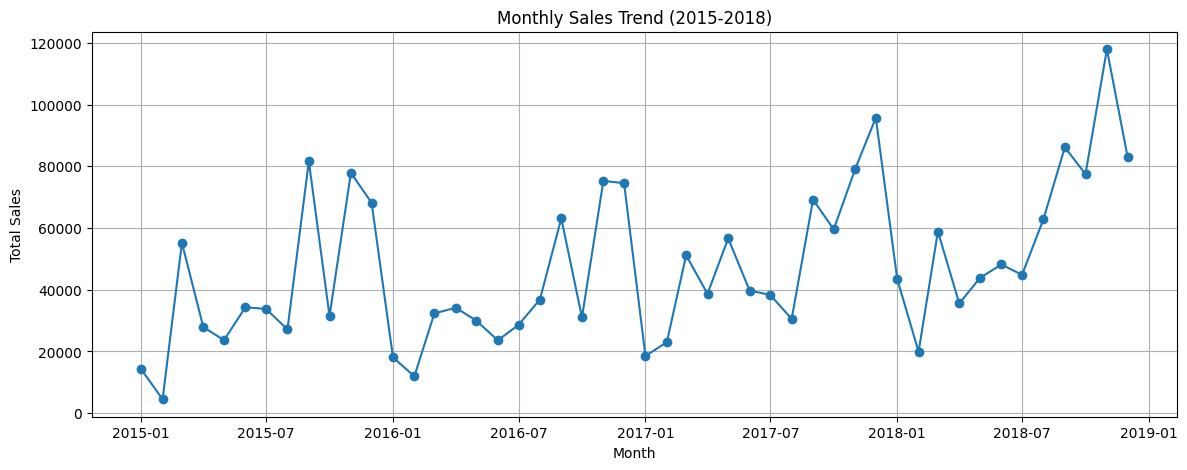

In [75]:
import matplotlib.pyplot as plt

monthly_ts = monthly_sales.copy()
monthly_ts['YearMonth'] = monthly_ts['YearMonth'].dt.to_timestamp()
monthly_ts = monthly_ts.set_index('YearMonth')

plt.figure(figsize=(14,5))
plt.plot(monthly_ts.index, monthly_ts['Sales'], marker='o')
plt.title('Monthly Sales Trend (2015-2018)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.savefig('charts/monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

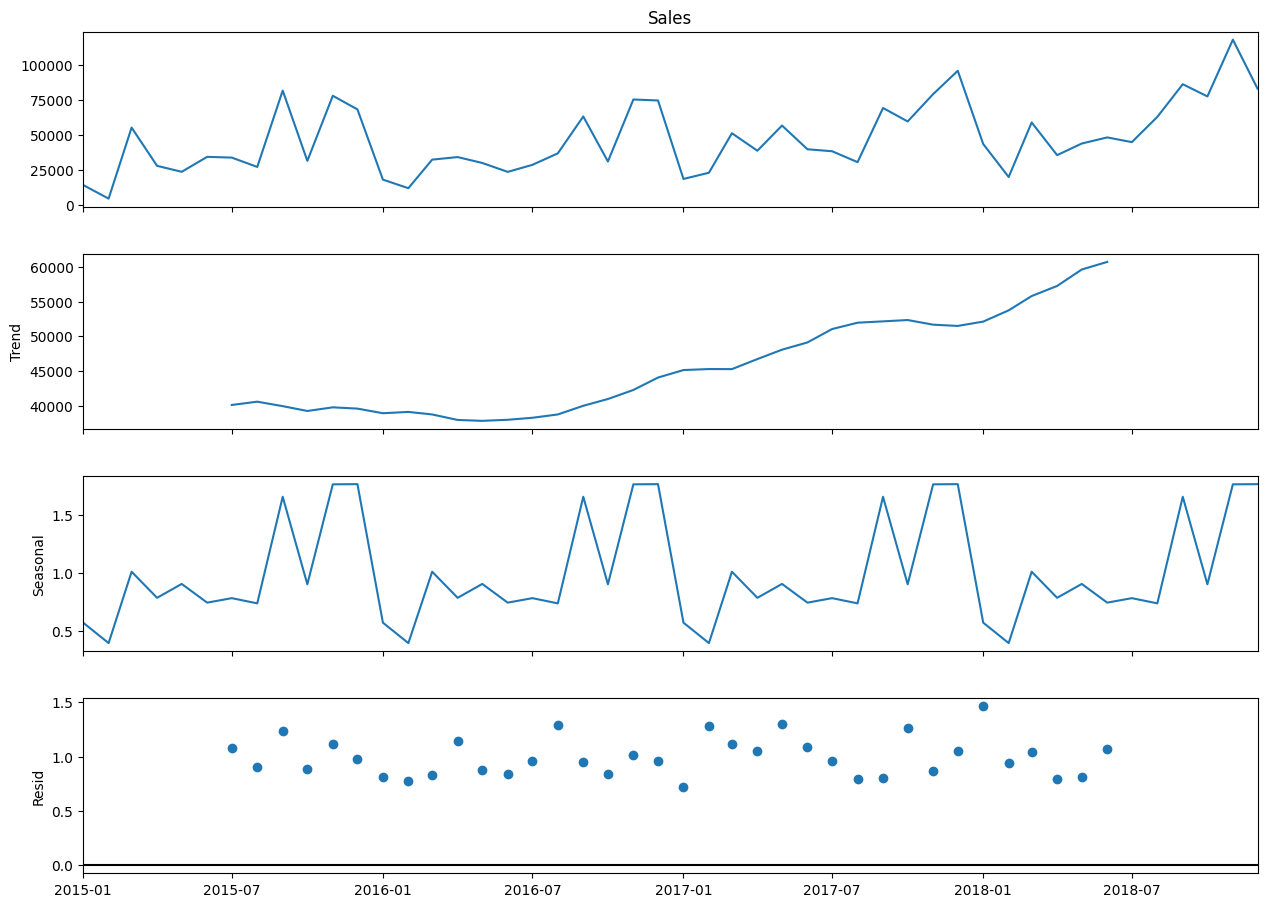

In [76]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly_ts['Sales'], model='multiplicative', period=12)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
fig.savefig('charts/decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation**

*Trend is flat around 40K for the first 18 months (2015-mid 2016), then rises steadily to ~60K by late 2018 , growth is concentrated in the second half of the observed period.*

*Seasonality is strong and highly consistent: sales peak every year in September, November, and December (seasonal index ~1.7-1.8, i.e., 70-80% above baseline) and dip every year in January & February (index ~0.4-0.6, i.e., 40-60% below baseline).*

 *Residuals stay close to 1.0 (little unexplained noise) throughout most of the series, except for a clear spike to ~1.45 around early 2018, indicating one month where actual sales significantly exceeded what trend and seasonality alone would predict.*

In [31]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_ts['Sales'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
Critical Values: {'1%': np.float64(-3.5778480370438146), '5%': np.float64(-2.925338105429433), '10%': np.float64(-2.6007735310095064)}


*A stationary time series is one whose statistical behavior doesn't change over time : its average level, its spread (variance), and the way today's value relates to yesterday's value all stay roughly consistent throughout the series. Imagine looking at any random 12 month window of the data  in a stationary series, each window would look statistically similar to any other window (similar average, similar ups and downs). In a non stationary series, different time windows look different ; for example, the average keeps climbing over time, or the swings get bigger, so an early window and a late window don't resemble each other. Forecasting models like SARIMA work more reliably on stationary data because they assume the underlying statistical pattern isn't shifting under them.*

*The ADF test result (p value = 0.00028) statistically indicates stationarity, rejecting the null hypothesis of a unit root. This is somewhat counter to the visual trend observed in the decomposition; however, this can occur when a series has strong, regular seasonality (which resets the series each year) combined with a limited sample size (48 months), both of which can make a series appear stationary to the ADF test despite a slow underlying trend. Given this, we proceed to Task 3 without additional differencing, but flag this as a modeling consideration for SARIMA's d parameter.*

In [32]:
monthly_ts['Sales_diff'] = monthly_ts['Sales'].diff()

# Re-run ADF test on the differenced series (drop the first NaN row)
result_diff = adfuller(monthly_ts['Sales_diff'].dropna())
print('ADF Statistic (differenced):', result_diff[0])
print('p-value (differenced):', result_diff[1])
print('Critical Values:', result_diff[4])

ADF Statistic (differenced): -8.727061830353264
p-value (differenced): 3.2669175472797e-14
Critical Values: {'1%': np.float64(-3.626651907578875), '5%': np.float64(-2.9459512825788754), '10%': np.float64(-2.6116707716049383)}


*The original monthly series was already stationary per the ADF test (p=0.00028), likely because strong annual seasonality causes the series to 'reset' each year despite a slow underlying trend. Applying first-order differencing further strengthened this result substantially (p=3.27e-14), confirming that any residual trend is fully removed after one differencing step. This supports using d=1 in the SARIMA model in Task 3.*

**Task 3 — Sales Forecasting using 3 Different Models**

In [33]:
train = monthly_ts.iloc[:-3]
test = monthly_ts.iloc[-3:]

print(train.shape, test.shape)
print(test.index)

(45, 2) (3, 2)
DatetimeIndex(['2018-10-01', '2018-11-01', '2018-12-01'], dtype='datetime64[ns]', name='YearMonth', freq=None)


**Model 1 : SARIMA (Statistical Model)**

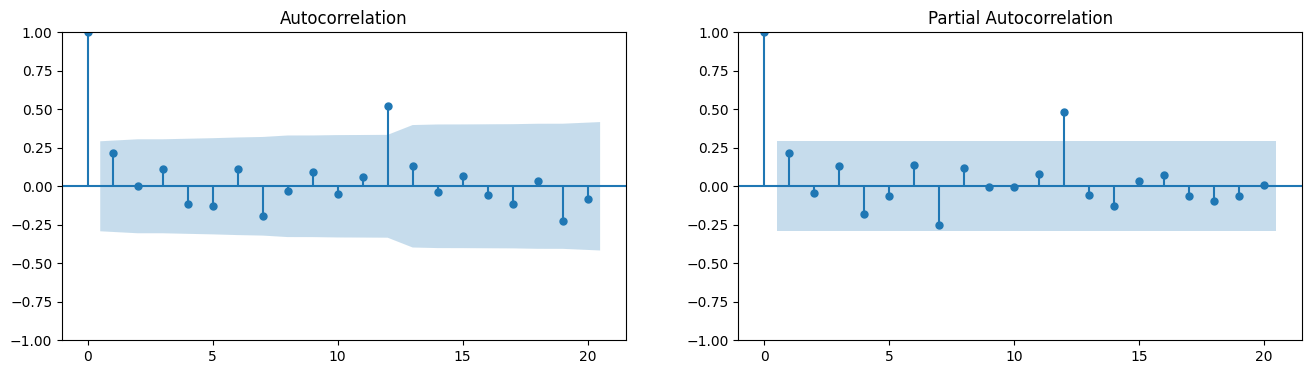

In [77]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16,4))
plot_acf(train['Sales'], ax=axes[0], lags=20)
plot_pacf(train['Sales'], ax=axes[1], lags=20)
plt.savefig('charts/acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

*ACF and PACF plots show no strong direct autocorrelation in lags 1-11, but both show a clear, significant spike at lag 12  confirming the yearly seasonality already found in decomposition. Based on this, we select p=1, q=1 for the non seasonal terms (no strong alternative signal), and P=1, Q=1 for the seasonal terms (matching the lag 12 spike), with d=1 (from ADF differencing test) and D=1 (seasonal differencing due to strong yearly pattern), m=12 (monthly data, yearly cycle).*

In [35]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train['Sales'],order=(1,1,1),seasonal_order=(1,1,1,12),enforce_stationarity=False,enforce_invertibility=False)

sarima_result = model.fit(disp=False)
print(sarima_result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Wed, 08 Jul 2026   AIC                            398.775
Time:                                    10:52:35   BIC                            403.227
Sample:                                01-01-2015   HQIC                           399.389
                                     - 09-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

*With only 45 monthly training observations (~3.75 yearly cycles), SARIMAX struggled to reliably estimate the seasonal AR/MA terms (ar.S.L12 p=0.680, ma.S.L12 p=0.433 , both statistically insignificant), and the covariance matrix was near singular. This is a known limitation of applying SARIMA's seasonal component to short time series , seasonal parameter estimation typically needs 4+ full cycles for stability.*

In [36]:
forecast = sarima_result.get_forecast(steps=3)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

print(forecast_mean)
print(forecast_ci)

2018-10-01    60331.792095
2018-11-01    91458.220224
2018-12-01    97167.570946
Freq: MS, Name: predicted_mean, dtype: float64
             lower Sales    upper Sales
2018-10-01  33867.663904   86795.920286
2018-11-01  64294.739753  118621.700696
2018-12-01  69727.828587  124607.313305


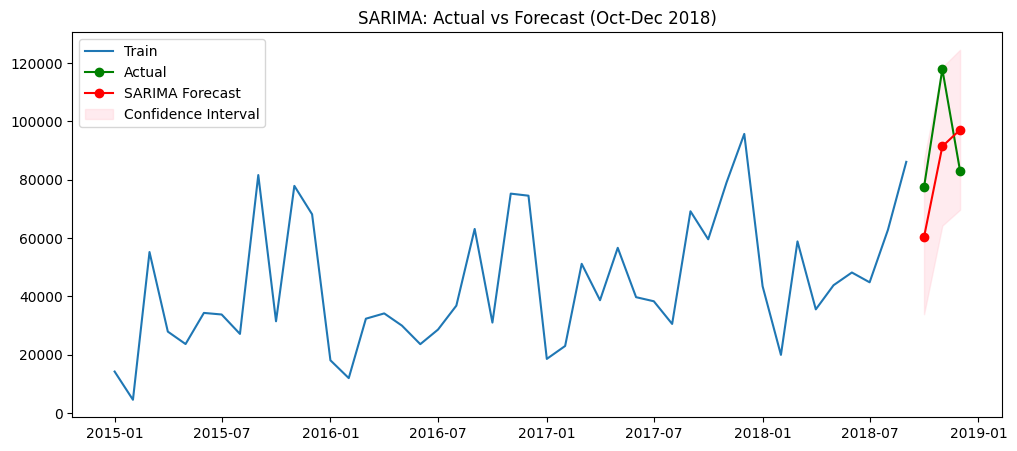

In [78]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train['Sales'], label='Train')
plt.plot(test.index, test['Sales'], label='Actual', marker='o', color='green')
plt.plot(forecast_mean.index, forecast_mean, label='SARIMA Forecast', marker='o', color='red')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1], color='pink', alpha=0.3, label='Confidence Interval')
plt.legend()
plt.title('SARIMA: Actual vs Forecast (Oct-Dec 2018)')
plt.savefig('charts/sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual = test['Sales'].values
predicted = forecast_mean.values

mae_sarima = mean_absolute_error(actual, predicted)
rmse_sarima = np.sqrt(mean_squared_error(actual, predicted))
mape_sarima = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"MAE: {mae_sarima:.2f}")
print(f"RMSE: {rmse_sarima:.2f}")
print(f"MAPE: {mape_sarima:.2f}%")

MAE: 19244.49
RMSE: 19950.07
MAPE: 20.53%


*SARIMA achieved a MAPE of ~20.5% on the Oct-Dec 2018 holdout, correctly capturing the overall upward trend but failing to capture the sharp Nov to Dec pullback, likely due to unreliable seasonal parameter estimation from limited training data (45 months, ~3.75 seasonal cycles).*

**Model 2 : Facebook Prophet (Industry-standard Forecasting Tool)**

In [39]:
prophet_train = train.reset_index()[['YearMonth', 'Sales']].rename(columns={'YearMonth':'ds', 'Sales':'y'})
prophet_train.head()

,ds,y
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


In [40]:
!pip install prophet -q

In [41]:
from prophet import Prophet

prophet_model = Prophet()
prophet_model.fit(prophet_train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [42]:
future = prophet_model.make_future_dataframe(periods=3, freq='MS')
future.tail()

,ds
43,2018-08-01
44,2018-09-01
45,2018-10-01
46,2018-11-01
47,2018-12-01


In [43]:
forecast_prophet = prophet_model.predict(future)
forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3)

,ds,yhat,yhat_lower,yhat_upper
45,2018-10-01,51083.663790,42332.587172,58943.776670
46,2018-11-01,90045.402141,81940.634676,97556.309684
47,2018-12-01,89661.190745,82103.016234,98050.421928


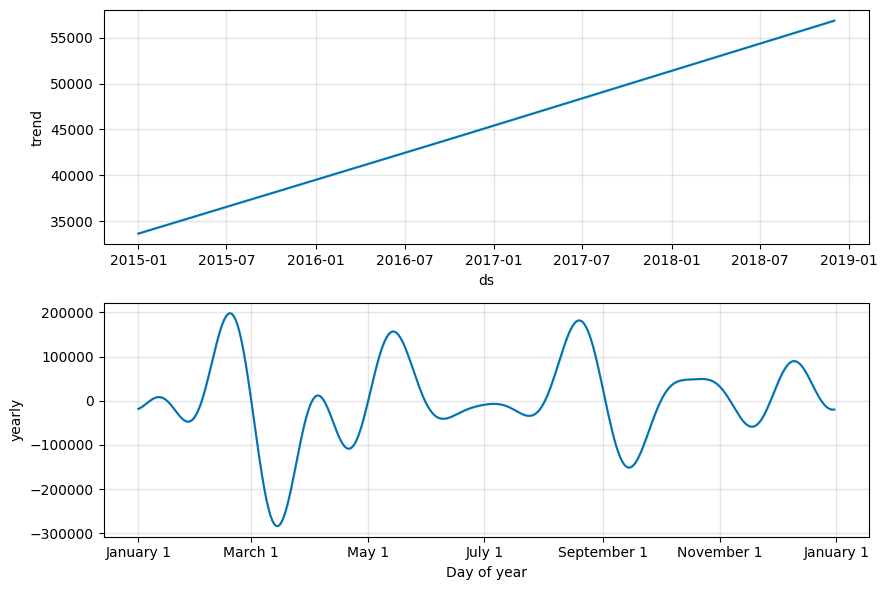

In [79]:
fig2 = prophet_model.plot_components(forecast_prophet)
fig2.savefig('charts/prophet_components_default.png', dpi=150, bbox_inches='tight')
plt.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


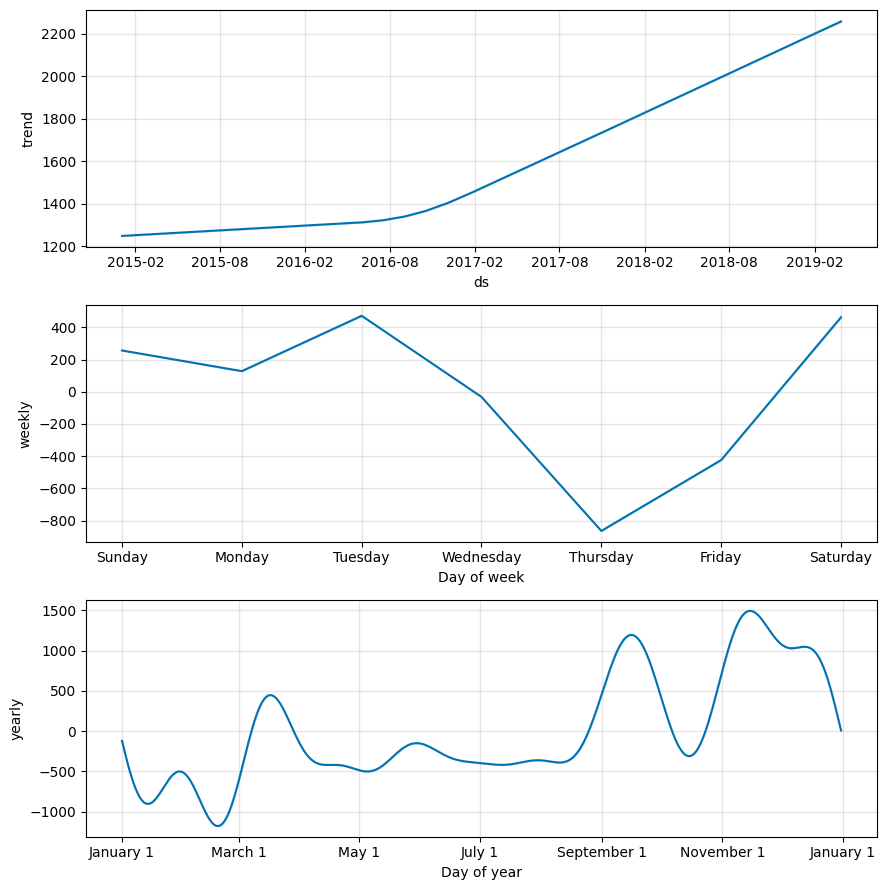

In [80]:
prophet_daily = daily_sales.rename(columns={'Order Date':'ds', 'Sales':'y'})

prophet_daily_model = Prophet()
prophet_daily_model.fit(prophet_daily)

future_daily = prophet_daily_model.make_future_dataframe(periods=90)  # just to generate components, not for real forecasting
forecast_daily = prophet_daily_model.predict(future_daily)

fig3 = prophet_daily_model.plot_components(forecast_daily)
fig3.savefig('charts/prophet_weekly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
predicted_prophet = forecast_prophet['yhat'].tail(3).values
actual = test['Sales'].values

mae_prophet = mean_absolute_error(actual, predicted_prophet)
rmse_prophet = np.sqrt(mean_squared_error(actual, predicted_prophet))
mape_prophet = np.mean(np.abs((actual - predicted_prophet) / actual)) * 100

print(f"MAE: {mae_prophet:.2f}")
print(f"RMSE: {rmse_prophet:.2f}")
print(f"MAPE: {mape_prophet:.2f}%")

MAE: 20296.01
RMSE: 22487.47
MAPE: 21.89%


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


MAE: 21671.67, RMSE: 22618.10, MAPE: 24.43%


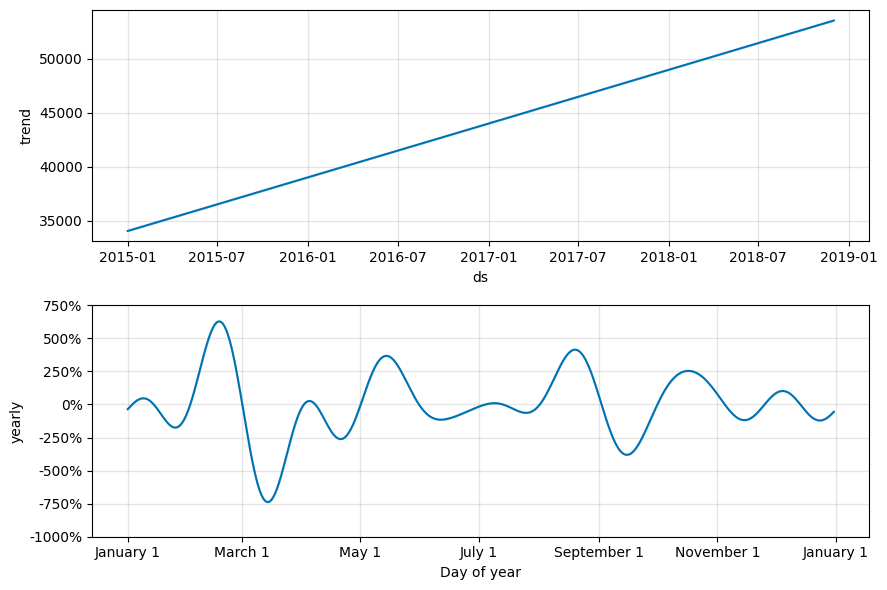

In [81]:
prophet_model2 = Prophet(seasonality_mode='multiplicative')
prophet_model2.fit(prophet_train)

forecast_prophet2 = prophet_model2.predict(future)

predicted_prophet2 = forecast_prophet2['yhat'].tail(3).values
mae_prophet2 = mean_absolute_error(actual, predicted_prophet2)
rmse_prophet2 = np.sqrt(mean_squared_error(actual, predicted_prophet2))
mape_prophet2 = np.mean(np.abs((actual - predicted_prophet2) / actual)) * 100

print(f"MAE: {mae_prophet2:.2f}, RMSE: {rmse_prophet2:.2f}, MAPE: {mape_prophet2:.2f}%")

fig4 = prophet_model2.plot_components(forecast_prophet2)
fig4.savefig('charts/prophet_multiplicative_overfit.png', dpi=150, bbox_inches='tight')
plt.show()

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


MAE: 21541.97, RMSE: 22056.47, MAPE: 23.12%


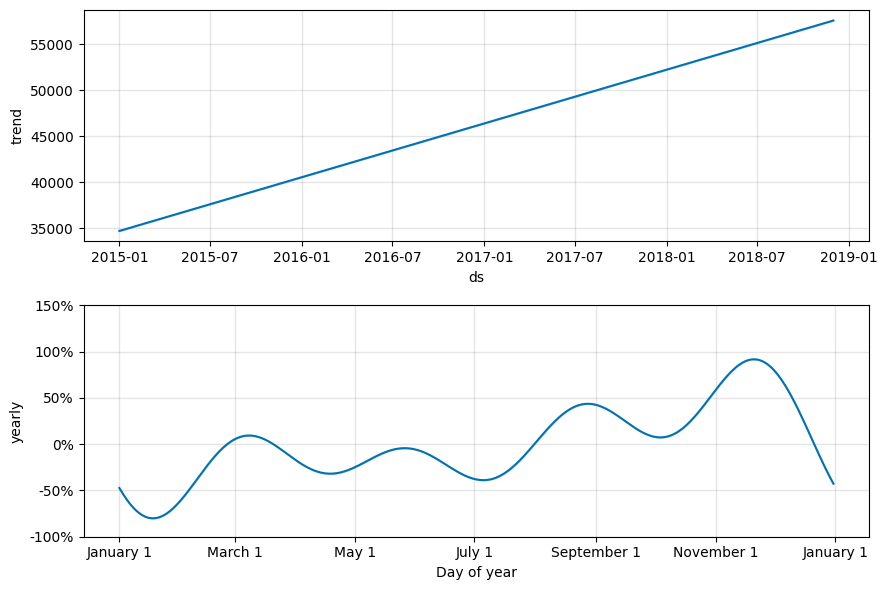

In [82]:
prophet_model3 = Prophet(seasonality_mode='multiplicative', yearly_seasonality=4)
prophet_model3.fit(prophet_train)

forecast_prophet3 = prophet_model3.predict(future)

predicted_prophet3 = forecast_prophet3['yhat'].tail(3).values
mae_prophet3 = mean_absolute_error(actual, predicted_prophet3)
rmse_prophet3 = np.sqrt(mean_squared_error(actual, predicted_prophet3))
mape_prophet3 = np.mean(np.abs((actual - predicted_prophet3) / actual)) * 100

print(f"MAE: {mae_prophet3:.2f}, RMSE: {rmse_prophet3:.2f}, MAPE: {mape_prophet3:.2f}%")

fig5 = prophet_model3.plot_components(forecast_prophet3)
fig5.savefig('charts/prophet_final_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

In [55]:
print(forecast_prophet3[['ds','yhat']].tail(3))

           ds           yhat
45 2018-10-01   61125.637313
46 2018-11-01   90151.253266
47 2018-12-01  103546.900804


*Although Prophet's default additive model scored marginally better on this 3 month test window (MAPE 21.89% vs 23.12%), its yearly seasonality component was severely overfit given the limited training data (implying seasonal swings up to -750%, which would produce negative sales). We instead select the multiplicative model with reduced seasonality flexibility (yearly_seasonality=4) as it produces a realistic, interpretable seasonal curve, at the cost of a marginally higher error on this small test set. With only 3 test points, this small MAPE difference is not a reliable basis for preferring the overfit model.*

**Model 3 : XGBoost for Time Series (ML-based Approach)**

In [49]:
ml_df = monthly_ts.copy()

ml_df['lag1'] = ml_df['Sales'].shift(1)
ml_df['lag2'] = ml_df['Sales'].shift(2)
ml_df['lag3'] = ml_df['Sales'].shift(3)
ml_df['rolling_mean_3'] = ml_df['Sales'].shift(1).rolling(window=3).mean()

ml_df['Month'] = ml_df.index.month
ml_df['Quarter'] = ml_df.index.quarter

def get_season(month):
    if month in [12,1,2]:
        return 0  # Winter
    elif month in [3,4,5]:
        return 1  # Spring
    elif month in [6,7,8]:
        return 2  # Summer
    else:
        return 3  # Fall

ml_df['Season'] = ml_df['Month'].apply(get_season)

ml_df.head(10)

,Sales,Sales_diff,lag1,lag2,lag3,rolling_mean_3,Month,Quarter,Season
YearMonth,,,,,,,,,
2015-01-01,14205.7070,NaN,NaN,NaN,NaN,NaN,1,1,0
2015-02-01,4519.8920,-9685.8150,14205.7070,NaN,NaN,NaN,2,1,0
2015-03-01,55205.7970,50685.9050,4519.8920,14205.7070,NaN,NaN,3,1,1
2015-04-01,27906.8550,-27298.9420,55205.7970,4519.8920,14205.7070,24643.798667,4,2,1
2015-05-01,23644.3030,-4262.5520,27906.8550,55205.7970,4519.8920,29210.848000,5,2,1
2015-06-01,34322.9356,10678.6326,23644.3030,27906.8550,55205.7970,35585.651667,6,2,2
2015-07-01,33781.5430,-541.3926,34322.9356,23644.3030,27906.8550,28624.697867,7,3,2
2015-08-01,27117.5365,-6664.0065,33781.5430,34322.9356,23644.3030,30582.927200,8,3,2
2015-09-01,81623.5268,54505.9903,27117.5365,33781.5430,34322.9356,31740.671700,9,3,3


In [50]:
ml_df_clean = ml_df.dropna()
print(ml_df_clean.shape)

features = ['lag1', 'lag2', 'lag3', 'rolling_mean_3', 'Month', 'Quarter', 'Season']
X = ml_df_clean[features]
y = ml_df_clean['Sales']

print(X.shape, y.shape)

(45, 9)
(45, 7) (45,)


In [51]:
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
y_train, y_test = y.iloc[:-3], y.iloc[-3:]

print(X_train.shape, X_test.shape)

(42, 7) (3, 7)


In [52]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)
print(xgb_predictions)

[68123.   87622.9  69508.99]


In [53]:
mae_xgb = mean_absolute_error(y_test, xgb_predictions)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_predictions))
mape_xgb = np.mean(np.abs((y_test.values - xgb_predictions) / y_test.values)) * 100

print(f"MAE: {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAPE: {mape_xgb:.2f}%")

MAE: 17720.59
RMSE: 19906.46
MAPE: 18.01%


In [54]:
importances = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

Month             0.722030
rolling_mean_3    0.086631
lag2              0.086279
lag1              0.054248
lag3              0.036971
Season            0.013841
Quarter           0.000000
dtype: float32


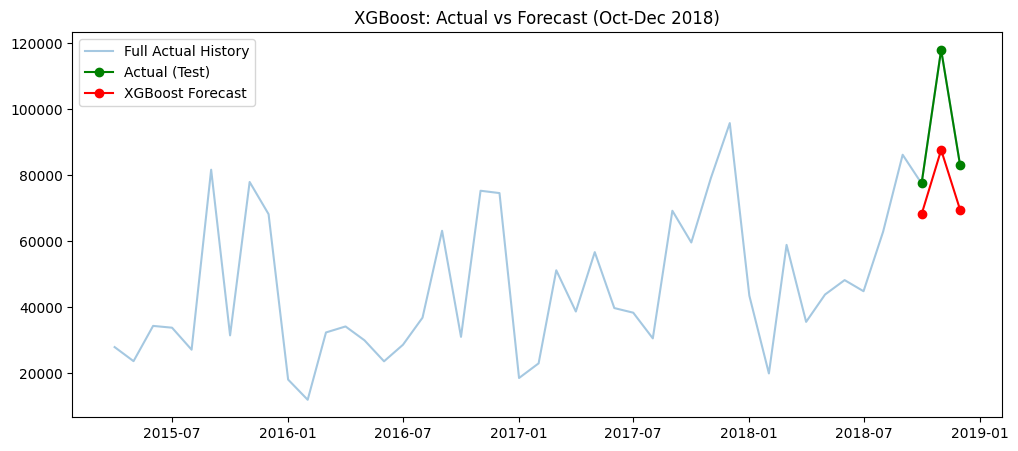

In [83]:
plt.figure(figsize=(12,5))
plt.plot(y.index, y.values, label='Full Actual History', alpha=0.4)
plt.plot(y_test.index, y_test.values, label='Actual (Test)', marker='o', color='green')
plt.plot(y_test.index, xgb_predictions, label='XGBoost Forecast', marker='o', color='red')
plt.legend()
plt.title('XGBoost: Actual vs Forecast (Oct-Dec 2018)')
plt.savefig('charts/xgboost_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

**Model Comparison Table:**

## Model Comparison Table

| Model    | MAE      | RMSE     | MAPE   | Forecast Oct 2018 | Forecast Nov 2018 | Forecast Dec 2018 |
|----------|----------|----------|--------|-------------------|-------------------|-------------------|
| SARIMA   | 19244.49 | 19950.07 | 20.53% | 60331.79          | 91458.22          | 97167.57          |
| Prophet  | 21541.97 | 22056.47 | 23.12% | 61125.64          | 90151.25          | 103546.90         |
| XGBoost  | 17720.59 | 19906.46 | 18.01% | 68123.00          | 87622.90          | 69508.99          |

**Actual values (for reference):** Oct = 77448.13, Nov = 117938.16, Dec = 83030.39

**Recommended model: XGBoost** as it has lowest MAE, RMSE, and MAPE. Driven primarily by the `Month` feature (72% importance), effectively re learning the seasonal pattern from Tasks 1-2. However, all three models underestimate the November spike, with XGBoost missing it by ~26% due to tree based models' inability to extrapolate beyond training range. A production system should apply a manual safety buffer during known peak months (Nov/Dec) regardless of model choice.

*XGBoost achieved the lowest error across all three metrics (MAE 17,720.59, RMSE 19,906.46, MAPE 18.01%), driven primarily by the Month feature (72% importance), effectively relearning the seasonal pattern identified in Tasks 1-2. However, XGBoost's tree based nature means it cannot extrapolate beyond values seen in training, causing it to significantly undershoot November's spike (predicted 87,623 vs actual 117,938, ~26% miss) , a real limitation for a business relying on it to plan for extreme peak months. SARIMA had comparable RMSE but visibly failed to capture the Nov-Dec reversal shape. Prophet, once corrected for overfitting, produced the most interpretable seasonal decomposition but the highest error on this small test set. Given the tiny 3 month test window, no single model's edge is highly statistically robust , I would recommend XGBoost for average case forecasting accuracy, but flag that all three models underestimate extreme peak months, and a business should apply a manual safety buffer during known high season periods (Nov/Dec) regardless of model choice.*

**Task 4 = Product Category & Region Level Forecasting**

In [56]:
def prepare_monthly_features(data, filter_col=None, filter_val=None):
    if filter_col:
        data = data[data[filter_col] == filter_val]

    monthly = data.groupby(data['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
    monthly.columns = ['YearMonth', 'Sales']
    monthly['YearMonth'] = monthly['YearMonth'].dt.to_timestamp()
    monthly = monthly.set_index('YearMonth')

    full_range = pd.date_range(start=monthly.index.min(), end=monthly.index.max(), freq='MS')
    monthly = monthly.reindex(full_range, fill_value=0)
    monthly.index.name = 'YearMonth'

    monthly['lag1'] = monthly['Sales'].shift(1)
    monthly['lag2'] = monthly['Sales'].shift(2)
    monthly['lag3'] = monthly['Sales'].shift(3)
    monthly['rolling_mean_3'] = monthly['Sales'].shift(1).rolling(window=3).mean()
    monthly['Month'] = monthly.index.month
    monthly['Quarter'] = monthly.index.quarter
    monthly['Season'] = monthly['Month'].apply(get_season)

    return monthly.dropna()

In [57]:
test_full = prepare_monthly_features(df)
print(test_full.shape)
test_full.head()

(45, 8)


,Sales,lag1,lag2,lag3,rolling_mean_3,Month,Quarter,Season
YearMonth,,,,,,,,
2015-04-01,27906.8550,55205.7970,4519.8920,14205.707,24643.798667,4,2,1
2015-05-01,23644.3030,27906.8550,55205.7970,4519.892,29210.848000,5,2,1
2015-06-01,34322.9356,23644.3030,27906.8550,55205.797,35585.651667,6,2,2
2015-07-01,33781.5430,34322.9356,23644.3030,27906.855,28624.697867,7,3,2
2015-08-01,27117.5365,33781.5430,34322.9356,23644.303,30582.927200,8,3,2


In [58]:
def train_and_forecast(monthly_features_df, label):
    features = ['lag1', 'lag2', 'lag3', 'rolling_mean_3', 'Month', 'Quarter', 'Season']
    X = monthly_features_df[features]
    y = monthly_features_df['Sales']

    X_train, X_test = X.iloc[:-3], X.iloc[-3:]
    y_train, y_test = y.iloc[:-3], y.iloc[-3:]

    model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mape = np.mean(np.abs((y_test.values - preds) / y_test.values)) * 100

    print(f"{label} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

    return pd.Series(preds, index=y_test.index, name=label)

In [59]:
segments = {
    'Furniture': ('Category', 'Furniture'),
    'Technology': ('Category', 'Technology'),
    'Office Supplies': ('Category', 'Office Supplies'),
    'West': ('Region', 'West'),
    'East': ('Region', 'East'),
}

forecasts = {}
for label, (col, val) in segments.items():
    seg_df = prepare_monthly_features(df, filter_col=col, filter_val=val)
    forecasts[label] = train_and_forecast(seg_df, label)

Furniture -> MAE: 5325.54, RMSE: 6200.53, MAPE: 19.54%
Technology -> MAE: 10822.75, RMSE: 14023.81, MAPE: 25.68%
Office Supplies -> MAE: 2676.93, RMSE: 3055.48, MAPE: 9.29%
West -> MAE: 2287.87, RMSE: 2692.73, MAPE: 9.56%
East -> MAE: 14012.40, RMSE: 14289.83, MAPE: 45.42%


In [60]:
seg_df_east = prepare_monthly_features(df, filter_col='Region', filter_val='East')
X_east = seg_df_east[['lag1','lag2','lag3','rolling_mean_3','Month','Quarter','Season']]
y_east = seg_df_east['Sales']

print("Actual:", y_east.iloc[-3:].values)
print("Predicted:", forecasts['East'].values)

Actual: [32295.24  45633.639 19285.486]
Predicted: [17810.365 28450.064 29654.225]


*East region shows an unusually high MAPE (45.42%) despite MAE/RMSE (~14K) being only moderately worse than other segments. This is driven by December 2018's unusually low actual sales (19,285), where even a modest ~10K dollar error translates into a large percentage error. This illustrates a known limitation of MAPE: it becomes unstable and can overstate model error when actual values are small. MAE/RMSE remain more reliable indicators of East's forecast quality in this case.*

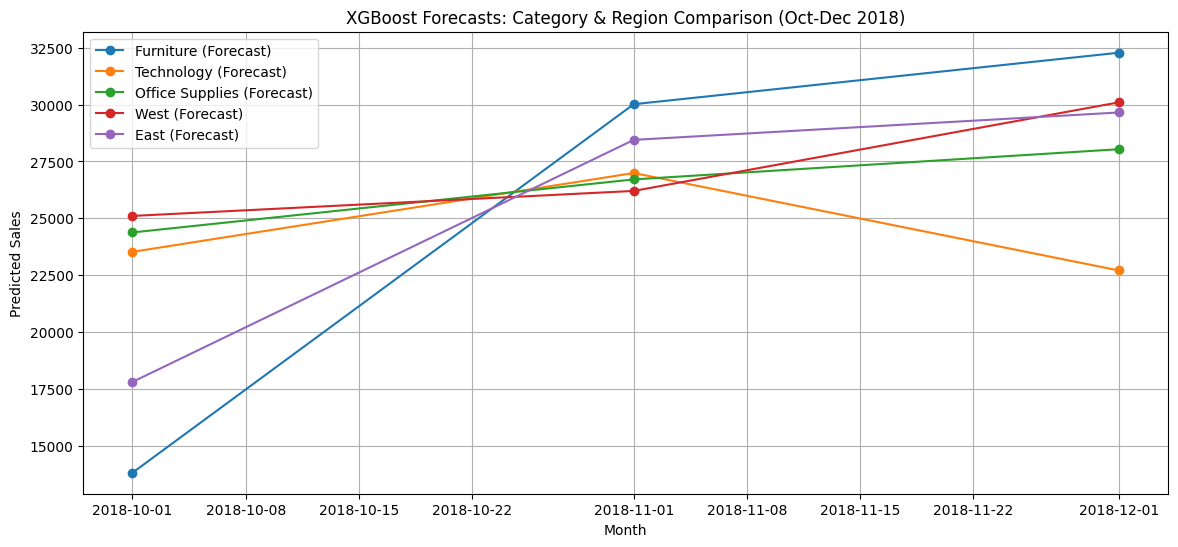

In [84]:
plt.figure(figsize=(14,6))

for label, preds in forecasts.items():
    plt.plot(preds.index, preds.values, marker='o', label=f'{label} (Forecast)')

plt.title('XGBoost Forecasts: Category & Region Comparison (Oct-Dec 2018)')
plt.xlabel('Month')
plt.ylabel('Predicted Sales')
plt.legend()
plt.grid(True)
plt.savefig('charts/category_region_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

*Furniture shows the strongest predicted growth (Oct→Dec: ~13.8K→32.3K), followed by West and Office Supplies trending upward. Technology is the only segment forecast to decline into December, despite being the highest-revenue category overall.*

**Task 5 = Anomaly Detection in Sales Data**

In [63]:
from sklearn.ensemble import IsolationForest

weekly = weekly_sales.copy()
weekly['YearMonth'] = weekly['YearMonth'].astype(str)  # keep for labeling

iso = IsolationForest(contamination=0.05, random_state=42)
weekly['anomaly_iso'] = iso.fit_predict(weekly[['Sales']])
# -1 = anomaly, 1 = normal

anomalies_iso = weekly[weekly['anomaly_iso'] == -1]
print(anomalies_iso)

                 YearMonth      Sales  anomaly_iso
0    2014-12-29/2015-01-04    304.508           -1
5    2015-02-02/2015-02-08    968.534           -1
7    2015-02-16/2015-02-22    224.912           -1
11   2015-03-16/2015-03-22  37703.665           -1
28   2015-07-13/2015-07-19   1387.686           -1
36   2015-09-07/2015-09-13  29959.137           -1
55   2016-01-18/2016-01-24    358.522           -1
154  2017-12-11/2017-12-17  25449.800           -1
200  2018-10-29/2018-11-04  29017.467           -1
202  2018-11-12/2018-11-18  30572.447           -1
204  2018-11-26/2018-12-02  35998.900           -1


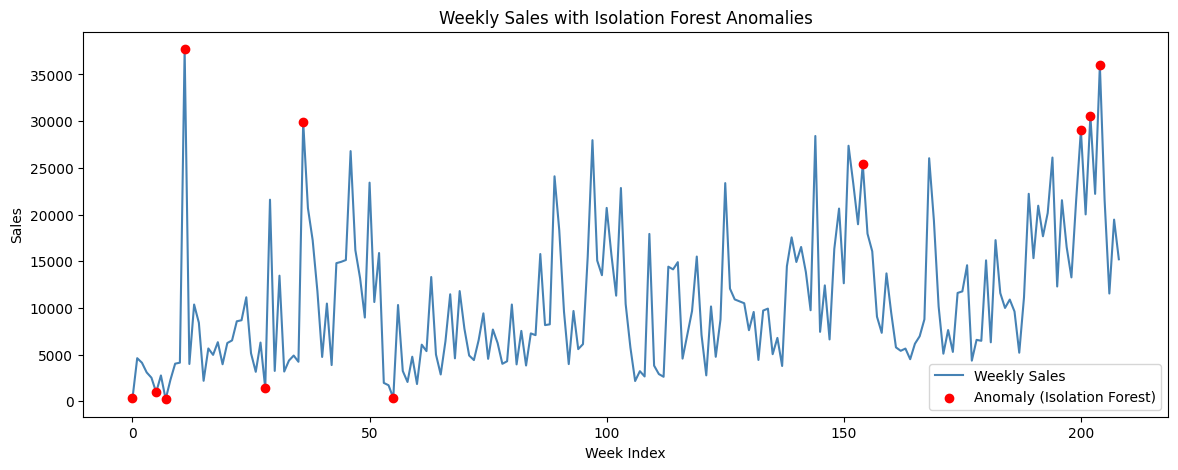

In [85]:
plt.figure(figsize=(14,5))
plt.plot(range(len(weekly)), weekly['Sales'], label='Weekly Sales', color='steelblue')
plt.scatter(anomalies_iso.index, anomalies_iso['Sales'], color='red', label='Anomaly (Isolation Forest)', zorder=5)
plt.title('Weekly Sales with Isolation Forest Anomalies')
plt.xlabel('Week Index')
plt.ylabel('Sales')
plt.legend()
plt.savefig('charts/anomalies_isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()

*  *2014-12-29/2015-01-04 (304), 2015-02 weeks (968, 224), 2016-01-18 (358): unusually low sales , likely genuine post holiday/new year lull, consistent with our Task 1 finding that Jan/Feb are the weakest months every year.*
*  *2015-03-16/2015-03-22 (37703): unusually high for such an early date , possibly a large bulk/enterprise order, or a one-off promotional week.*
*  *2015-09-07/2015-09-13 (29959), 2017-12-11/2017-12-17 (25449): high weeks aligning with back to school (Sep) and holiday season (Dec) , matches known seasonality.*
*  *2018-10-29 to 2018-12-02 (29017, 30572, 35998): three consecutive high weeks right before the Nov/Dec peak, this cluster likely explains part of why November 2018's actual spike was so large (the highest we've seen all project) possibly a stronger-than-usual holiday season or a specific large promotional push that year.*

In [67]:
weekly['rolling_mean'] = weekly['Sales'].shift(1).rolling(window=4, min_periods=4).mean()
weekly['rolling_std'] = weekly['Sales'].shift(1).rolling(window=4, min_periods=4).std()
weekly['z_score'] = (weekly['Sales'] - weekly['rolling_mean']) / weekly['rolling_std']

anomalies_z = weekly[np.abs(weekly['z_score']) > 2]
print(anomalies_z[['YearMonth','Sales','z_score']])
print(f"\nTotal Z-score anomalies: {len(anomalies_z)}")

                 YearMonth       Sales    z_score
5    2015-02-02/2015-02-08    968.5340  -2.752352
7    2015-02-16/2015-02-22    224.9120  -2.242690
9    2015-03-02/2015-03-08   4030.7280   2.102431
11   2015-03-16/2015-03-22  37703.6650  19.060372
22   2015-06-01/2015-06-07   8569.9480   2.327130
24   2015-06-15/2015-06-21  11139.4446   2.792849
26   2015-06-29/2015-07-05   3158.4000  -2.120808
29   2015-07-20/2015-07-26  21590.0800   8.119383
36   2015-09-07/2015-09-13  29959.1370  35.956949
46   2015-11-16/2015-11-22  26793.6235   2.638264
61   2016-02-29/2016-03-06   6066.2554   2.295874
63   2016-03-14/2016-03-20  13310.1360   4.745273
74   2016-05-30/2016-06-05   9418.9440   2.275457
80   2016-07-11/2016-07-17  10366.1590   2.777064
86   2016-08-22/2016-08-28  15773.4780   5.364995
89   2016-09-12/2016-09-18  24095.9600   3.564238
96   2016-10-31/2016-11-06  15492.8670   3.814566
97   2016-11-07/2016-11-13  27965.3492   4.112502
109  2017-01-30/2017-02-05  17926.3680   9.043908


In [68]:
iso_weeks = set(anomalies_iso['YearMonth'])
z_weeks = set(anomalies_z['YearMonth'])

overlap = iso_weeks & z_weeks
print("Weeks flagged by BOTH methods:", overlap)
print("Count:", len(overlap))

Weeks flagged by BOTH methods: {'2018-11-26/2018-12-02', '2015-09-07/2015-09-13', '2015-02-02/2015-02-08', '2015-03-16/2015-03-22', '2018-10-29/2018-11-04', '2015-02-16/2015-02-22'}
Count: 6


*Isolation Forest flagged 11 anomalies (constrained to ~5% of weeks by design), while Z score flagged 40 ( nearly 4x more ) due to using a fixed threshold (>2 std) with a small, noise sensitive 4 week rolling window rather than a fixed anomaly rate. Both methods agree on the most extreme spikes (e.g., 2015-09-07 week at 29,959 and 2015-03-16 week at 37,703), but disagree substantially on borderline cases. This suggests: Isolation Forest is better suited when you need a fixed, predictable number of flagged points (e.g., for a dashboard alert budget), while Z score is more sensitive to local volatility but requires careful window size tuning to avoid over flagging.*

*6 weeks were flagged by both methods , including the most extreme spikes (2015-09-07, 2015-03-16) and clear seasonal lows (Feb 2015 weeks). This overlap on the strongest signals gives confidence that these are genuine anomalies rather than method specific noise, while the non overlapping weeks likely represent borderline cases sensitive to each method's specific threshold choice.*

**Task 6 = Product Demand Segmentation using Clustering**

In [70]:
subcat_features = df.groupby('Sub-Category').agg(
    total_sales=('Sales', 'sum'),
    avg_order_value=('Sales', 'mean')
).reset_index()

yearly_subcat = df.groupby(['Sub-Category','Year'])['Sales'].sum().reset_index()
pivot_subcat = yearly_subcat.pivot(index='Sub-Category', columns='Year', values='Sales')
pivot_subcat['growth_rate'] = ((pivot_subcat[2018] - pivot_subcat[2015]) / pivot_subcat[2015]) * 100

monthly_subcat = df.groupby(['Sub-Category', df['Order Date'].dt.to_period('M')])['Sales'].sum().reset_index()
volatility = monthly_subcat.groupby('Sub-Category')['Sales'].std().reset_index()
volatility.columns = ['Sub-Category', 'volatility']

cluster_data = subcat_features.merge(pivot_subcat[['growth_rate']], on='Sub-Category').merge(volatility, on='Sub-Category')
cluster_data.head(20)

,Sub-Category,total_sales,avg_order_value,growth_rate,volatility
0,Accessories,164186.7000,217.178175,145.055961,2579.994809
1,Appliances,104618.4030,227.926804,165.242912,1821.621539
2,Art,26705.4100,34.019631,49.649531,330.488343
3,Binders,200028.7850,134.067550,65.778638,3848.223648
4,Bookcases,113813.1987,503.598224,49.846598,2220.405080
5,Chairs,322822.7310,531.833165,20.954677,4407.232960
6,Copiers,146248.0940,2215.880212,479.729510,5500.774391
7,Envelopes,16128.0460,65.032444,-12.121345,228.218688
8,Fasteners,3001.9600,14.027850,30.468364,48.742229
9,Furnishings,89212.0180,95.823865,106.824969,1360.017867


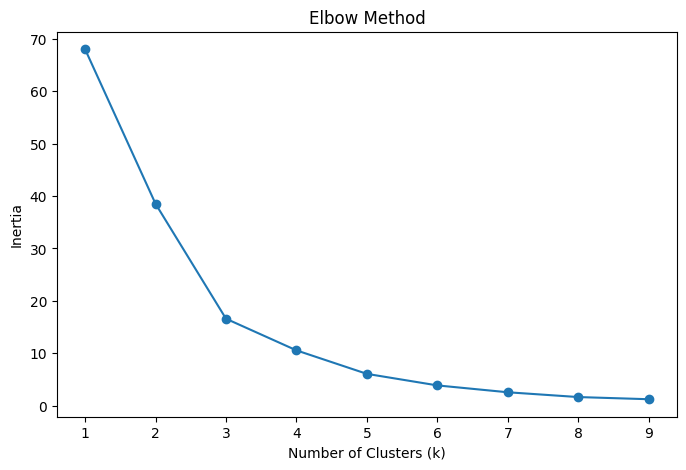

In [86]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features_for_clustering = ['total_sales', 'avg_order_value', 'growth_rate', 'volatility']
X_cluster = cluster_data[features_for_clustering]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

inertia = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.savefig('charts/elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

In [72]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_data['Cluster'] = kmeans_final.fit_predict(X_scaled)

cluster_data[['Sub-Category','total_sales','avg_order_value','growth_rate','volatility','Cluster']].sort_values('Cluster')

,Sub-Category,total_sales,avg_order_value,growth_rate,volatility,Cluster
0,Accessories,164186.7000,217.178175,145.055961,2579.994809,0
3,Binders,200028.7850,134.067550,65.778638,3848.223648,0
5,Chairs,322822.7310,531.833165,20.954677,4407.232960,0
14,Storage,219343.3920,263.633885,38.366108,2822.084310,0
13,Phones,327782.4480,374.180877,35.557607,4052.718221,0
16,Tables,202810.6280,645.893720,33.078016,3224.082504,0
6,Copiers,146248.0940,2215.880212,479.729510,5500.774391,1
2,Art,26705.4100,34.019631,49.649531,330.488343,2
7,Envelopes,16128.0460,65.032444,-12.121345,228.218688,2
4,Bookcases,113813.1987,503.598224,49.846598,2220.405080,2


| Cluster | Sub-Categories | Label |
|---|---|---|
| 0 | Accessories, Binders, Chairs, Storage, Phones, Tables | High Volume, Established Demand |
| 1 | Copiers | High-Value Outlier / Niche High-Growth |
| 2 | Art, Envelopes, Bookcases, Fasteners, Furnishings, Paper, Labels, Supplies, Appliances | Low-to-Moderate Volume, Stable/Mixed Demand |
| 3 | Machines | Declining Demand, High-Value |

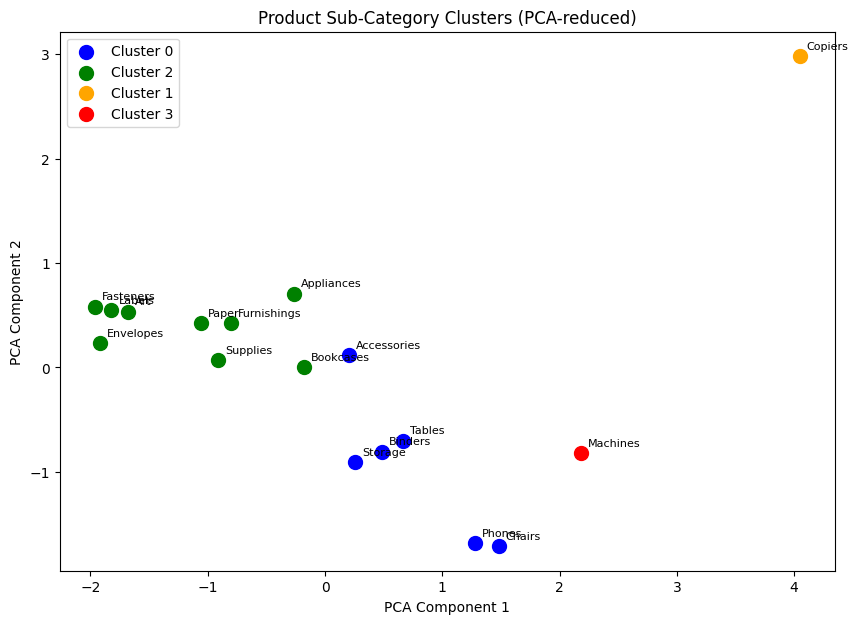

In [87]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

cluster_data['PCA1'] = pca_result[:,0]
cluster_data['PCA2'] = pca_result[:,1]

plt.figure(figsize=(10,7))
colors = ['blue','orange','green','red']
for cl in cluster_data['Cluster'].unique():
    subset = cluster_data[cluster_data['Cluster']==cl]
    plt.scatter(subset['PCA1'], subset['PCA2'], label=f'Cluster {cl}', s=100, color=colors[cl])

for i, row in cluster_data.iterrows():
    plt.annotate(row['Sub-Category'], (row['PCA1'], row['PCA2']), fontsize=8, xytext=(5,5), textcoords='offset points')

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Product Sub-Category Clusters (PCA-reduced)')
plt.title('Product Sub-Category Clusters (PCA-reduced)')
plt.legend()
plt.savefig('charts/clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

**Cluster 0 —> High Volume, Established Demand** (Accessories, Binders, Chairs, Storage, Phones, Tables)
Maintain steady, well stocked inventory levels year round given consistent demand, but keep extra safety stock ahead of Sep-Nov (per Task 1/2 seasonality) since these are high volatility, high revenue items where stockouts are costly.

**Cluster 1 —> High Value Outlier / Niche High Growth** (Copiers)
Low stock volume but high per unit value , consider a made to order or pre order model rather than holding large inventory, given the extreme 480% growth rate suggests demand is still emerging/unpredictable; monitor closely rather than mass-stock.

**Cluster 2 —> Low to Moderate Volume, Stable/Mixed Demand** (Art, Envelopes, Bookcases, Fasteners, Furnishings, Paper, Labels, Supplies, Appliances)
Standard, moderate stock levels with periodic reordering; low volatility means predictable replenishment cycles work well here , lower priority for safety buffers.

**Cluster 3 —> Declining Demand, High Value** (Machines)
Reduce future stock commitments given the -29.8% growth trend; avoid overstocking, consider clearance/discount strategy for existing inventory, and investigate why demand is declining (product lifecycle, competition, substitution by other sub categories).